In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from math import e
from scipy.optimize import minimize
from IPython.display import clear_output
from scipy import optimize
from scipy.stats import norm
import pickle
from scipy import integrate
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import locale
import matplotlib as mpl

In [2]:
locale.setlocale(locale.LC_NUMERIC, "pt_BR.utf8")
plt.rcParams['axes.formatter.use_locale'] = True

In [3]:
# Configure text rendering to match your document's LaTeX engine
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex", 
    "font.family": "serif",      # Matches standard LaTeX Computer Modern Font
    "text.usetex": True,         # Forces LaTeX text processing
    "pgf.rcfonts": False,        # Ignores default Python fonts
})

In [4]:
# for error propagation
sigma_yj = 0.001 # mol/mol
sigma_P = 133 #	Pa
sigma_T = 1 # K
R = 8.314 # J/mol/K

In [5]:
pd.options.display.max_seq_items = 2000

In [6]:
data = pd.read_excel('data.ods')

In [7]:
data['T (ºC)'] = data['T_R_K'] - 273

In [8]:
data = data.loc[(data['CINÉTICA'] == 1) | (data['DESATIVAÇÃO'] == 1)]
# data = data.loc[data.t_h < 159]
# data = data.loc[((data['F_C2H6_s_mol_s'] != 0) & (data['F_C3H8_s_mol_s'] != 0))]

In [9]:
data.columns

Index(['t_h', 'CINÉTICA', 'PLOT', 'DESATIVAÇÃO', 'BM', 'P_abs_Pa', 'T_R_K',
       'F_H2_e_mol_s', 'F_CO_e_mol_s', 'F_H2O_e_mol_s', 'F_CO2_e_mol_s',
       'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s', 'F_H2O_s_mol_s',
       'X_CO', 'X_H2', 'm_cat_g', 'CODE', 'm_SEP_acum (g)', 'frac_cera',
       'w_C7', 'w_C8', 'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13', 'w_C14',
       'w_C15', 'w_C16', 'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21', 'w_C22',
       'w_C23', 'w_C24', 'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29', 'w_C30',
       'w_C31', 'w_C32', 'w_C33', 'w_C34', 'w_C35', 'w_C36', 'LIQ_SAMPLE',
       'w_C7_olef', 'w_C8_olef', 'w_C9_olef', 'w_C10_olef', 'w_C11_olef',
       'w_C12_olef', 'w_C13_olef', 'w_C14_olef', 'w_C15_olef', 'w_C16_olef',
       'w_C17_olef', 'w_C18_olef', 'v_s (mL/min)', 'erro_v_s (mL/min)',
       'T_amb (ºC)', 'P_amb (Pa)', 'T (ºC)'],
      dtype='str')

In [10]:
data = data.copy()

In [11]:
data[['F_Olef_C2_e', 'F_Olef_C3_e', 
    'F_Olef_C9_e', 'F_Olef_C10_e', 'F_Olef_C11_e', 
   'F_Olef_C12_e', 'F_Olef_C13_e', 'F_Olef_C14_e', 'F_Olef_C15_e', 
     'F_Olef_C16_e', 'F_Olef_C17_e', 'F_Olef_C18_e',

    
    'F_C1_e', 'F_C2_e', 'F_C3_e', 'F_C9_e', 'F_C10_e', 'F_C11_e', 
      'F_C12_e', 'F_C13_e', 'F_C14_e', 'F_C15_e', 'F_C16_e', 'F_C17_e', 'F_C18_e',
      'F_C19_e', 'F_C20_e', 'F_C21_e', 'F_C22_e', 'F_C23_e', 'F_C24_e', 'F_C25_e', 
      'F_C26_e', 'F_C27_e', 'F_C28_e', 'F_C29_e', 'F_C30_e', 'F_C31_e', 'F_C32_e', 
      'F_C33_e', 'F_C34_e', 'F_C35_e', 'F_C36_e']] = 0

In [12]:
# doing raw mass balance to check errors

In [13]:
data['$m_{gas,in}$ (g/s)'] = data['F_H2_e_mol_s']*2 + data['F_CO_e_mol_s']*(12+16)

In [14]:
data['$m_{gas,out}$ (g/s)'] = (data['F_H2_s_mol_s']*2 + data['F_CO_s_mol_s']*(12+16)
                              + data['F_CO2_s_mol_s']*44 + data['F_CH4_s_mol_s']*16
                              + data['F_C2H6_s_mol_s']*((2*12)+6) + data['F_C3H8_s_mol_s']*((3*12)+8)
                              + data['F_C2H4_s_mol_s']*((2*12) + 4)
                              )

In [15]:
# data['$m_{liq,out}$ (g/s)'] = data['$m_{gas,in}$ (g/s)'] - data['$m_{gas,out}$ (g/s)']

In [16]:
data['$m_{in}$ (g/s)'] = data['$m_{gas,in}$ (g/s)']

In [17]:
data['t_s'] = data['t_h']*3600

In [18]:
data['$m_{in,cumul}$ (g)'] = integrate.cumulative_trapezoid(data['$m_{gas,in}$ (g/s)'], data['t_s'], initial = 0)

In [19]:
data[r'$m_{\mathrm{liq,cumul}}$ (g)'] = data['m_SEP_acum (g)']
edges = (data[r'$m_{\mathrm{liq,cumul}}$ (g)'].diff() != 0)

data['$m_{liq,out}$ (g/s)'] = data.loc[edges, r'$m_{\mathrm{liq,cumul}}$ (g)'].diff() / data.loc[edges, 't_s'].diff()
data['$m_{liq,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'].bfill()

In [20]:
data['$m_{gas,out,cumul}$ (g)'] = integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'], 
                                                             data['t_s'], initial = 0)

In [21]:
data['$m_{out,cumul}$ (g)'] = (integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'], 
                                                             data['t_s'], initial = 0)
                              + data[r'$m_{\mathrm{liq,cumul}}$ (g)']
                              )

In [22]:
data['MB_error_perc'] = 100*(data['$m_{in,cumul}$ (g)'] - 
                             data['$m_{out,cumul}$ (g)']) / data['$m_{in,cumul}$ (g)'].iloc[-1]

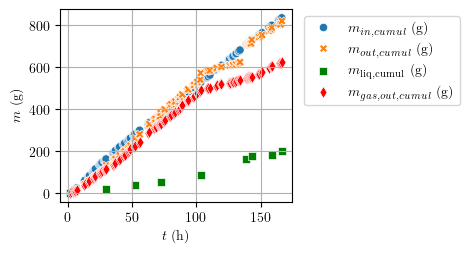

In [23]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'value',
             data=data[['t_h',
                        '$m_{in,cumul}$ (g)', 
                        '$m_{out,cumul}$ (g)',
                       ]].melt(id_vars = 't_h'), 
             hue = 'variable',
             style = 'variable',
             ax = ax)
sns.scatterplot(x='t_h', y = 'value',
             data=data.loc[edges][['t_h',
                        r'$m_{\mathrm{liq,cumul}}$ (g)',
                       ]].melt(id_vars = 't_h'), 
             label = r'$m_{\mathrm{liq,cumul}}$ (g)', color = 'g', marker = 's',
             ax = ax)
sns.scatterplot(x='t_h', y = 'value',
             data=data[['t_h',
                        '$m_{gas,out,cumul}$ (g)',
                       ]].melt(id_vars = 't_h'), 
             label = '$m_{gas,out,cumul}$ (g)',  color = 'r', marker = 'd',
             ax = ax)

plt.grid('both')
# plt.ylim(0,1)
# plt.xlim(0,10)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.xlabel('$t$ (h)')
plt.ylabel('$m$ (g)')
fig_name = 'MB_cumul.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [24]:
data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].min()

np.float64(-5.326675440798214)

In [25]:
data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].max()

np.float64(3.6586980439288794)

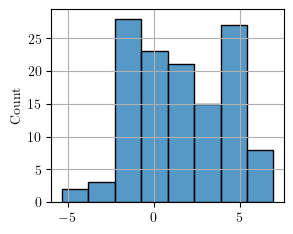

In [26]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.histplot(x = 'MB_error_perc',
             data=data)
ax.grid('both')
plt.xlabel('% MB error')

plt.show()

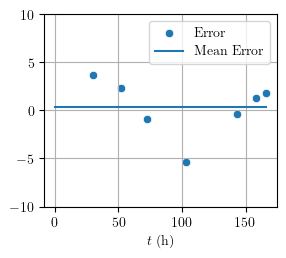

In [27]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'MB_error_perc',
             data=data.loc[data['LIQ_SAMPLE'] == 1],
             label = 'Error',
             ax = ax)

plt.grid('both')
plt.plot(np.linspace(0, data['t_h'].iloc[-1], 2), 
         (data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean(), 
          data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()), 
         label = 'Mean Error')
plt.ylim(-10,10)
# plt.xlim(0,80)
plt.legend()
plt.xlabel('$t$ (h)')
plt.ylabel('% MB error')
fig_name = 'MB_error.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [28]:
data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()

np.float64(0.3649374985832258)

In [29]:
data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].std()

np.float64(2.955136974103493)

In [30]:
# now closing the mass balance using the integral mass balance to get the aprox liquid % in the outlet

In [31]:
data['$m_{total}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'] + data['$m_{gas,out}$ (g/s)']
data[r'$\sigma_{m,total}$ (g/s)'] = data['$m_{total}$ (g/s)'] * 0.05 # max error is 5%

In [32]:
# recalculating inlet flow
y_H2_in = data['F_H2_e_mol_s'] / ( data['F_H2_e_mol_s'] + data['F_CO_e_mol_s'] )
y_CO_in = data['F_CO_e_mol_s'] / ( data['F_H2_e_mol_s'] + data['F_CO_e_mol_s'] )
MM_in = 2 * y_H2_in + 28 * y_CO_in
sigma_MM_in = ( ( 2 * sigma_yj ) ** 2 + ( 28 * sigma_yj ) ** 2 ) ** ( 1 / 2 )
F_in = data['$m_{total}$ (g/s)'] / MM_in
sigma_F_in = ( 
        ( data[r'$\sigma_{m,total}$ (g/s)'] / MM_in ) ** 2
      + ( data['$m_{total}$ (g/s)'] * sigma_MM_in / ( MM_in ** 2 ) ) ** 2
    ) ** ( 1 / 2 )
data['F_H2_e_mol_s'] = y_H2_in * F_in
data['F_CO_e_mol_s'] = y_CO_in * F_in

data['sigma_F_CO_in_mol_s'] = ( ( F_in * sigma_yj ) ** 2 + ( y_CO_in * sigma_F_in ) ** 2 ) ** ( 1 / 2 )
data['sigma_F_H2_in_mol_s'] = ( ( F_in * sigma_yj ) ** 2 + ( y_H2_in * sigma_F_in ) ** 2 ) ** ( 1 / 2 )

In [33]:
data['$m_{liq,out}$ (g/s)'].mean()

np.float64(0.0003486497658245917)

In [34]:
# using oxygen elemental balance to correct water flow and get a better estimation of liquid hydrocarbon flow
data['F_H2O_s_mol_s'] = data['F_CO_e_mol_s'] - data['F_CO_s_mol_s'] - 2*data['F_CO2_s_mol_s']
data['$m_{H_2O,out}$ (g/s)'] = data['F_H2O_s_mol_s']*18

In [35]:
# fração de cera no produto líquido medida na balanca
# antes da correção pelo BM da água
data['frac_cera'].mean()

np.float64(0.3401558867016793)

In [36]:
# m C5+ out after H2O elemental balance correction
data['$m_{C5+,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'] - data['$m_{H_2O,out}$ (g/s)']
data['$m_{C5+,out}$ (g/s)'].mean()

np.float64(0.00013930891783051175)

In [37]:
data['$m_{H_2O,out}$ (g/s)'].mean()

np.float64(0.00020934084799407977)

In [38]:
# fração de cera no produto líquido depois da correção pelo BM da água
data['frac_cera'] = data['$m_{C5+,out}$ (g/s)']/data['$m_{liq,out}$ (g/s)']
data['frac_cera'].mean()

np.float64(0.40473769116405706)

In [39]:
data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
     'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[[
       'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13', 'w_C14', 'w_C15', 'w_C16',
       'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21', 'w_C22', 'w_C23', 'w_C24',
       'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29', 'w_C30', 'w_C31', 'w_C32',
       'w_C33', 'w_C34', 'w_C35', 'w_C36',
        'w_C7_olef', 'w_C8_olef',
       'w_C9_olef', 'w_C10_olef', 'w_C11_olef', 'w_C12_olef', 'w_C13_olef',
       'w_C14_olef', 'w_C15_olef', 'w_C16_olef', 'w_C17_olef', 'w_C18_olef'       
               ]].multiply(
    data['$m_{C5+,out}$ (g/s)'], axis = 'index')

# molar masses of liquid hydrocarbons
MM_PARAFIN = [n*12+2*n+2 for n in range(9,37)]
MM_OLEF = [n*12+2*n for n in range(9,19)]
MM = np.concat((MM_PARAFIN, MM_OLEF))

# to remove Performance Warning
# PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 
# `frame.insert` many times, which has poor performance.  Consider joining all columns 
# at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
data = data.copy()

# F = mass flow/molar mass
data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
                                 ]].divide(MM, axis = 1)
data = data.copy()

/tmp/ipykernel_38184/1736902401.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['F_C9', 'F_C10',


In [40]:
data['T_R_C'] = data['T_R_K'] - 273.15
data['H2_CO'] = data['F_H2_e_mol_s']/data['F_CO_e_mol_s']
data['F_C1_C3_exp'] = (data['F_CH4_s_mol_s'] + data['F_C2H4_s_mol_s'] 
                       + data['F_C2H6_s_mol_s'] + data['F_C3H8_s_mol_s'])
data['F_C5+_exp'] = data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
       ]].sum(axis=1)
# data['alpha'] = (
#         (2.48e-15*data['P_abs_Pa']**2 - 1.19e-8*data['P_abs_Pa'] + 0.01597)*data['T_R_K'] +
#         (-1.5397e-12*data['P_abs_Pa']**2 + 6.8763e-6*data['P_abs_Pa'] - 7.7249)*(data['F_H2_e_mol_s']/data['F_CO_e_mol_s'])
#         )

In [41]:
# recalculating X on reconciled data
data['X_CO'] = (data['F_CO_e_mol_s'] - data['F_CO_s_mol_s']) / data['F_CO_e_mol_s']
data['X_H2'] = (data['F_H2_e_mol_s'] - data['F_H2_s_mol_s']) / data['F_H2_e_mol_s']

In [42]:
data['v_s (m³/s)'] = data['v_s (mL/min)'] / ( 1000 * 1000 * 60 )
data['sigma_v_s (m³/s)'] = data['erro_v_s (mL/min)'] / ( 1000 * 1000 * 60 )

In [43]:
data['T_amb (K)'] = data['T_amb (ºC)'] - 273.15

y_CO_out = data.F_CO_s_mol_s / data[['F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s']].sum(axis = 'columns')
y_H2_out = data.F_H2_s_mol_s / data[['F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s']].sum(axis = 'columns')
y_CO2_out = data.F_CO2_s_mol_s / data[['F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s']].sum(axis = 'columns')
y_CH4_out = data.F_CH4_s_mol_s / data[['F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s']].sum(axis = 'columns')
y_C2H4_out = data.F_C2H4_s_mol_s / data[['F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s']].sum(axis = 'columns')
y_C2H6_out = data.F_C2H6_s_mol_s / data[['F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s']].sum(axis = 'columns')
y_C3H8_out = data.F_C3H8_s_mol_s / data[['F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s']].sum(axis = 'columns')

data['sigma_F_CO_out_mol_s'] = (
      ( data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_yj / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CO_out * data['v_s (m³/s)'] * sigma_P / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CO_out * data['P_amb (Pa)'] * data['sigma_v_s (m³/s)'] / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CO_out * data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_T / ( R * data['T_amb (K)'] ** 2 ) ) ** 2
    ) ** (1/2)

data['sigma_F_H2_out_mol_s'] = (
      ( data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_yj / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_H2_out * data['v_s (m³/s)'] * sigma_P / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_H2_out * data['P_amb (Pa)'] * data['sigma_v_s (m³/s)'] / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_H2_out * data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_T / ( R * data['T_amb (K)'] ** 2 ) ) ** 2
    ) ** (1/2)

data['sigma_F_CO2_out_mol_s'] = (
      ( data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_yj / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CO_out * data['v_s (m³/s)'] * sigma_P / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CO_out * data['P_amb (Pa)'] * data['sigma_v_s (m³/s)'] / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CO_out * data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_T / ( R * data['T_amb (K)'] ** 2 ) ) ** 2
    ) ** (1/2)

data['sigma_F_CH4_out_mol_s'] = (
      ( data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_yj / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CH4_out * data['v_s (m³/s)'] * sigma_P / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CH4_out * data['P_amb (Pa)'] * data['sigma_v_s (m³/s)'] / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_CH4_out * data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_T / ( R * data['T_amb (K)'] ** 2 ) ) ** 2
    ) ** (1/2)

data['sigma_F_C2H4_out_mol_s'] = (
      ( data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_yj / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C2H4_out * data['v_s (m³/s)'] * sigma_P / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C2H4_out * data['P_amb (Pa)'] * data['sigma_v_s (m³/s)'] / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C2H4_out * data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_T / ( R * data['T_amb (K)'] ** 2 ) ) ** 2
    ) ** (1/2)

data['sigma_F_C2H6_out_mol_s'] = (
      ( data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_yj / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C2H6_out * data['v_s (m³/s)'] * sigma_P / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C2H6_out * data['P_amb (Pa)'] * data['sigma_v_s (m³/s)'] / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C2H6_out * data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_T / ( R * data['T_amb (K)'] ** 2 ) ) ** 2
    ) ** (1/2)

data['sigma_F_C3H8_out_mol_s'] = (
      ( data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_yj / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C3H8_out * data['v_s (m³/s)'] * sigma_P / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C3H8_out * data['P_amb (Pa)'] * data['sigma_v_s (m³/s)'] / ( R * data['T_amb (K)'] ) ) ** 2
    + ( y_C3H8_out * data['P_amb (Pa)'] * data['v_s (m³/s)'] * sigma_T / ( R * data['T_amb (K)'] ** 2 ) ) ** 2
    ) ** (1/2)

data['sigma_F_gas_out'] = (
    data['sigma_F_CO_out_mol_s']**2 + data['sigma_F_H2_out_mol_s']**2
    + data['sigma_F_CO2_out_mol_s']**2 + data['sigma_F_CH4_out_mol_s']**2
    + data['sigma_F_C2H4_out_mol_s']**2 + data['sigma_F_C2H6_out_mol_s']**2 
    + data['sigma_F_C3H8_out_mol_s']**2
) ** ( 1 / 2 )

In [44]:
data['sigma_X_CO'] = (
      ( data['F_CO_s_mol_s'] * data['sigma_F_CO_in_mol_s'] / ( data['F_CO_e_mol_s'] ** 2 ) ) ** 2
    + ( data['sigma_F_CO_out_mol_s'] / data['F_CO_e_mol_s'] ) ** 2
) ** ( 1 / 2 )

data['sigma_X_H2'] = (
      ( data['F_H2_s_mol_s'] * data['sigma_F_H2_in_mol_s'] / ( data['F_H2_e_mol_s'] ** 2 ) ) ** 2
    + ( data['sigma_F_H2_out_mol_s'] / data['F_H2_e_mol_s'] ) ** 2
) ** ( 1 / 2 )

In [45]:
F_w_dict = {'F_C9': 'w_C9',
 'F_C10': 'w_C10',
 'F_C11': 'w_C11',
 'F_C12': 'w_C12',
 'F_C13': 'w_C13',
 'F_C14': 'w_C14',
 'F_C15': 'w_C15',
 'F_C16': 'w_C16',
 'F_C17': 'w_C17',
 'F_C18': 'w_C18',
 'F_C19': 'w_C19',
 'F_C20': 'w_C20',
 'F_C21': 'w_C21',
 'F_C22': 'w_C22',
 'F_C23': 'w_C23',
 'F_C24': 'w_C24',
 'F_C25': 'w_C25',
 'F_C26': 'w_C26',
 'F_C27': 'w_C27',
 'F_C28': 'w_C28',
 'F_C29': 'w_C29',
 'F_C30': 'w_C30',
 'F_C31': 'w_C31',
 'F_C32': 'w_C32',
 'F_C33': 'w_C33',
 'F_C34': 'w_C34',
 'F_C35': 'w_C35',
 'F_C36': 'w_C36',
 'F_Olef_C9': 'w_C9_olef',
 'F_Olef_C10': 'w_C10_olef',
 'F_Olef_C11': 'w_C11_olef',
 'F_Olef_C12': 'w_C12_olef',
 'F_Olef_C13': 'w_C13_olef',
 'F_Olef_C14': 'w_C14_olef',
 'F_Olef_C15': 'w_C15_olef',
 'F_Olef_C16': 'w_C16_olef',
 'F_Olef_C17': 'w_C17_olef',
 'F_Olef_C18': 'w_C18_olef'}

In [46]:
MM_dict = {'F_C9': np.int64(128),
 'F_C10': np.int64(142),
 'F_C11': np.int64(156),
 'F_C12': np.int64(170),
 'F_C13': np.int64(184),
 'F_C14': np.int64(198),
 'F_C15': np.int64(212),
 'F_C16': np.int64(226),
 'F_C17': np.int64(240),
 'F_C18': np.int64(254),
 'F_C19': np.int64(268),
 'F_C20': np.int64(282),
 'F_C21': np.int64(296),
 'F_C22': np.int64(310),
 'F_C23': np.int64(324),
 'F_C24': np.int64(338),
 'F_C25': np.int64(352),
 'F_C26': np.int64(366),
 'F_C27': np.int64(380),
 'F_C28': np.int64(394),
 'F_C29': np.int64(408),
 'F_C30': np.int64(422),
 'F_C31': np.int64(436),
 'F_C32': np.int64(450),
 'F_C33': np.int64(464),
 'F_C34': np.int64(478),
 'F_C35': np.int64(492),
 'F_C36': np.int64(506),
 'F_Olef_C9': np.int64(126),
 'F_Olef_C10': np.int64(140),
 'F_Olef_C11': np.int64(154),
 'F_Olef_C12': np.int64(168),
 'F_Olef_C13': np.int64(182),
 'F_Olef_C14': np.int64(196),
 'F_Olef_C15': np.int64(210),
 'F_Olef_C16': np.int64(224),
 'F_Olef_C17': np.int64(238),
 'F_Olef_C18': np.int64(252)}


In [47]:
data['F_HCs_out'] = data[['F_C1_C3_exp', 'F_C5+_exp']].sum(axis = 'columns')

In [48]:
for key, value in F_w_dict.items():
    data[f'sigma_{key}'] = data[key] * 0.05

In [49]:
data['sigma_F_HCs_out'] = data['F_HCs_out'] * 0.05

In [50]:
# save reconciled data
with open('reconciled_data.pkl', 'wb') as f:
    pickle.dump(data, f)

In [51]:
data.to_excel('reconciled_data.ods')

In [52]:
kinetic_data = data.loc[data['CINÉTICA'] == 1.0].reset_index()
plot_data = data.loc[(data['DESATIVAÇÃO'] == 1.0) | (data['CINÉTICA'] == 1.0)].reset_index()
deactivation_data = data.loc[(data['DESATIVAÇÃO'] == 1)].reset_index()
data_mass_T = pd.read_excel('data_mass_T.ods')
data_mass_T = data_mass_T.loc[data_mass_T['MASS_T'] == 1.0].reset_index()
data_mass_T['-r_CO'] = -(data_mass_T['F_CO_s_mol_s'] - data_mass_T['F_CO_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['-r_H2'] = -(data_mass_T['F_H2_s_mol_s'] - data_mass_T['F_H2_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['T_R_C'] = data_mass_T['T_R_K'] - 273.15

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_38184/2649571313.py:4: SyntaxWarning: invalid escape sequence '\m'
  plot_data_kinetics.columns = ['t (h)', '$X_\mathrm{CO}$', '$X_\mathrm{H2}$', 'T (ºC)']
/tmp/ipykernel_38184/2649571313.py:4: SyntaxWarning: invalid escape sequence '\m'
  plot_data_kinetics.columns = ['t (h)', '$X_\mathrm{CO}$', '$X_\mathrm{H2}$', 'T (ºC)']


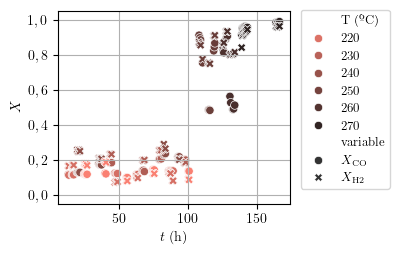

In [53]:
fig, ax = plt.subplots(figsize=(3,2.5))
plot_data_kinetics = data.loc[~(data.T_R_C > 250) | ~(data.X_CO < 0.4)].loc[(data.CINÉTICA == True) 
    & (data.DESATIVAÇÃO == False)][['t_h', 'X_CO', 'X_H2', 'T_R_C']]
plot_data_kinetics.columns = ['t (h)', '$X_\mathrm{CO}$', '$X_\mathrm{H2}$', 'T (ºC)']
plot_data_kinetics = plot_data_kinetics.melt(id_vars = ['t (h)', 'T (ºC)'])
sns.scatterplot(data = plot_data_kinetics,
               x = 't (h)', y = 'value', hue = 'T (ºC)', style = 'variable', palette = 'dark:salmon_r')

plt.grid('both')
plt.ylim(-0.05,1.05)
# plt.xlim(0,80)
plt.legend(ncols = 1, fontsize = 9, bbox_to_anchor=(1.02, 1.04))
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_kinetics.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [54]:
plot_data_kinetics

,t (h),T (ºC),variable,value
0,13.000000,222.0,$X_\mathrm{CO}$,0.116732
1,13.500000,222.0,$X_\mathrm{CO}$,0.112960
2,16.000000,222.0,$X_\mathrm{CO}$,0.114705
3,16.500000,222.0,$X_\mathrm{CO}$,0.114954
4,17.000000,222.0,$X_\mathrm{CO}$,0.114501
...,...,...,...,...
185,142.916667,271.0,$X_\mathrm{H2}$,0.944594
186,163.666667,271.0,$X_\mathrm{H2}$,0.961966
187,164.666667,271.0,$X_\mathrm{H2}$,0.958415
188,165.166667,271.0,$X_\mathrm{H2}$,0.963838


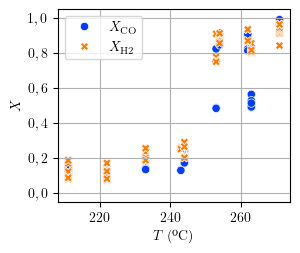

In [55]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.scatterplot(data = plot_data_kinetics,
               x = 'T (ºC)', y = 'value', hue = 'variable', style = 'variable', palette = 'bright')

plt.grid('both')
plt.ylim(-0.05,1.05)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$X$')
fig_name = 'X_vs_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

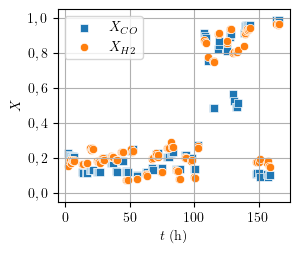

In [56]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y='X_CO',
             data=data, ax = ax, marker = 's', label = '$X_{CO}$')
sns.scatterplot(x='t_h', y='X_H2',
             data=data, ax = ax, marker = 'o', label = '$X_{H2}$')

plt.grid('both')
plt.ylim(-0.05,1.05)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
plt.show()

In [57]:
deactivation_data = data.loc[(data['DESATIVAÇÃO'] == 1)].reset_index()

In [58]:
deactivation_data.loc[deactivation_data.t_h < 100, 'X_CO'].std()

np.float64(0.016296677067736146)

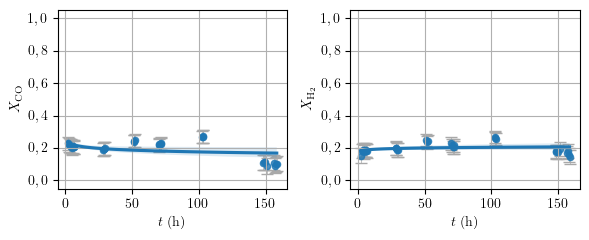

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(6,2.5))

ax[0].errorbar(
    x=deactivation_data['t_h'], 
    y=deactivation_data['X_CO'], 
    yerr=deactivation_data['sigma_X_CO'], 
    fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
    ecolor="darkgray",     # Error bar line color
    capsize=4,          # Width of the caps at the end of the error bars
    zorder=1,
    lw = 0.5,
)

ax[1].errorbar(
    x=deactivation_data['t_h'], 
    y=deactivation_data['X_H2'], 
    yerr=deactivation_data['sigma_X_H2'], 
    fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
    ecolor="darkgray",     # Error bar line color
    capsize=4,          # Width of the caps at the end of the error bars
    zorder=1,
    lw = 0.5,
)

sns.regplot(x='t_h', y='X_CO', logx = True,
             data=deactivation_data,
            ax = ax[0], scatter_kws={"s": 20})
sns.regplot(x='t_h', y='X_H2', logx = True,
             data=deactivation_data,
            ax = ax[1], scatter_kws={"s": 20})

ax[0].grid('both')
ax[0].set_ylim(-0.05,1.05)
# plt.xlim(0,80)
ax[0].set_xlabel(r'$t$ (h)')
ax[0].set_ylabel(r'$X_\mathrm{CO}$')

ax[1].grid('both')
ax[1].set_ylim(-0.05,1.05)
# plt.xlim(0,80)
ax[1].set_xlabel(r'$t$ (h)')
ax[1].set_ylabel(r'$X_\mathrm{H_2}$')


fig_name = 'X_deactivation.pdf'
plt.tight_layout()
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Tese/LaTeX_source_tese/figures/cinética_FTS/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

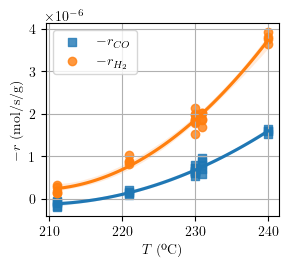

In [60]:
fig, ax = plt.subplots(figsize=(3,2.5))
# sns.lineplot(x='T_R_C', y='-r_CO',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_CO',
             data=data_mass_T, ax = ax, marker = 's', label = '$-r_{CO}$', order = 2)
# sns.lineplot(x='T_R_C', y='-r_H2',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_H2',
             data=data_mass_T, ax = ax, marker = 'o', label = '$-r_{H_2}$', order = 2)

plt.grid('both')
plt.legend()
# plt.ylim(0,None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$-r$ (mol/s/g)')
fig_name = 'T_vs_r_mass_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [61]:
kinetic_data.columns

Index(['index', 't_h', 'CINÉTICA', 'PLOT', 'DESATIVAÇÃO', 'BM', 'P_abs_Pa',
       'T_R_K', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'F_H2O_e_mol_s',
       'F_CO2_e_mol_s', 'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_CO2_s_mol_s', 'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
       'F_H2O_s_mol_s', 'X_CO', 'X_H2', 'm_cat_g', 'CODE', 'm_SEP_acum (g)',
       'frac_cera', 'w_C7', 'w_C8', 'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13',
       'w_C14', 'w_C15', 'w_C16', 'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21',
       'w_C22', 'w_C23', 'w_C24', 'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29',
       'w_C30', 'w_C31', 'w_C32', 'w_C33', 'w_C34', 'w_C35', 'w_C36',
       'LIQ_SAMPLE', 'w_C7_olef', 'w_C8_olef', 'w_C9_olef', 'w_C10_olef',
       'w_C11_olef', 'w_C12_olef', 'w_C13_olef', 'w_C14_olef', 'w_C15_olef',
       'w_C16_olef', 'w_C17_olef', 'w_C18_olef', 'v_s (mL/min)',
       'erro_v_s (mL/min)', 'T_amb (ºC)', 'P_amb (Pa)', 'T (ºC)',
       'F_Olef_C2_e', 'F_Olef_C3_e', 'F_O

In [62]:
rates_kinetic = pd.DataFrame()

rates_kinetic['-r_CO'] = (kinetic_data.F_CO_e_mol_s - kinetic_data.F_CO_s_mol_s) / kinetic_data.m_cat_g
rates_kinetic['-r_H2'] = (kinetic_data.F_H2_e_mol_s - kinetic_data.F_H2_s_mol_s) / kinetic_data.m_cat_g
rates_kinetic['ln -r_CO'] = np.log(rates_kinetic['-r_CO'])
rates_kinetic['ln -r_H2'] = np.log(rates_kinetic['-r_H2'])
rates_kinetic['T_R_C'] = kinetic_data.T_R_C
rates_kinetic['H2_CO'] = kinetic_data.H2_CO
filter_rates = ((rates_kinetic.H2_CO > 1.8) & (rates_kinetic.H2_CO < 2.2))
rates_kinetic = rates_kinetic.loc[filter_rates]

In [63]:
from sklearn import linear_model
reg_CO = linear_model.LinearRegression()
reg_CO.fit(rates_kinetic['T_R_C'].values.reshape(-1, 1), rates_kinetic['ln -r_CO'].values)
print(reg_CO.coef_, reg_CO.intercept_)

[0.02885804] -19.867927001976838


In [64]:
reg_H2 = linear_model.LinearRegression()
reg_H2.fit(rates_kinetic['T_R_C'].values.reshape(-1, 1), rates_kinetic['ln -r_H2'].values)
print(reg_H2.coef_, reg_H2.intercept_)

[0.03231102] -20.076799244457128


In [65]:
T = np.linspace(205, 275, 100)
r_CO_fit = np.exp(reg_CO.intercept_) * np.exp(reg_CO.coef_ * T)
r_H2_fit = np.exp(reg_H2.intercept_) * np.exp(reg_H2.coef_ * T)

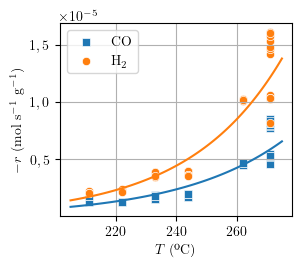

In [66]:
fig, ax = plt.subplots(figsize=(3,2.5))


sns.scatterplot(x='T_R_C', y='-r_CO',
             data=rates_kinetic, ax = ax, marker = 's', label = 'CO')
plt.plot(T, r_CO_fit)
# sns.lineplot(x='T_R_C', y='-r_H2',
#              data=data_mass_T, ax = ax)
sns.scatterplot(x='T_R_C', y='-r_H2',
             data=rates_kinetic, ax = ax, marker = 'o', label = r'$\mathrm{H_2}$')
plt.plot(T, r_H2_fit)

plt.grid('both')
plt.legend()
# plt.ylim(0,None)
plt.xlabel('$T$ (ºC)')
plt.ylabel(r'$-r~(\mathrm{mol~s^{-1}~g^{-1}})$')
fig_name = 'T_vs_r_kinetics.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()